In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import linregress

# Define file paths for different scenarios
files_historical = [f'D:/Jubjang/FWICMIP6/fwisa_ann_CNRM-CM6-1_historical_r{i}i1p1f2_g025.nc' for i in range(1, 31)]

# Function to load datasets from a list of file paths
def load_datasets(file_list):
    return [xr.open_mfdataset(file, combine='by_coords', engine='netcdf4') for file in file_list]

# Load datasets
datasets_historical = load_datasets(files_historical)

datasets_historical_aligned = xr.align(*datasets_historical, join="inner")

print("Datasets successfully loaded!")

Datasets successfully loaded!


In [2]:
# Define Earth's radius in meters
R = 6378137

# Latitude and longitude arrays (in degrees)
lon = datasets_historical[0].coords['lon']
lat = datasets_historical[0].coords['lat']

# Convert to radians
lon_radians = np.radians(lon)
lat_radians = np.radians(lat)

# Calculate the differences in longitude and latitude
delta_lon = np.diff(lon_radians)[0]  # Assuming regular grid
delta_lat = np.diff(lat_radians).mean()  # Take the mean for approximate spacing

# Calculate area for each grid cell
area = np.zeros((len(lat), len(lon)))  # Initialize area array to match full grid

for i in range(len(lat)):
    # Latitude bounds (extend to midpoints for full grid)
    if i == 0:  # Southernmost edge
        phi1 = lat_radians[i] - delta_lat / 2
        phi2 = lat_radians[i] + delta_lat / 2
    elif i == len(lat) - 1:  # Northernmost edge
        phi1 = lat_radians[i] - delta_lat / 2
        phi2 = lat_radians[i] + delta_lat / 2
    else:  # Interior latitudes
        phi1 = lat_radians[i] - delta_lat / 2
        phi2 = lat_radians[i] + delta_lat / 2

    # Calculate area for this latitude band
    area[i, :] = (R**2 * delta_lon * (np.sin(phi2) - np.sin(phi1)))

# Convert to square kilometers
area_km2 = area / 1e6

# Print or save the area array
print("Area array (in km^2):", area_km2)
print("Shape of area array:", area_km2.shape)


Area array (in km^2): [[1689.43277819 1689.43277819 1689.43277819 ... 1689.43277819
  1689.43277819 1689.43277819]
 [5065.08240325 5065.08240325 5065.08240325 ... 5065.08240325
  5065.08240325 5065.08240325]
 [8431.09035608 8431.09035608 8431.09035608 ... 8431.09035608
  8431.09035608 8431.09035608]
 ...
 [8431.09035608 8431.09035608 8431.09035608 ... 8431.09035608
  8431.09035608 8431.09035608]
 [5065.08240325 5065.08240325 5065.08240325 ... 5065.08240325
  5065.08240325 5065.08240325]
 [1689.43277819 1689.43277819 1689.43277819 ... 1689.43277819
  1689.43277819 1689.43277819]]
Shape of area array: (72, 144)


In [3]:
# Define latitude and longitude values
# Define latitude and longitude values (adjust based on your actual dataset)
num_lat = 72  # Number of latitude points
num_lon = 144  # Number of longitude points
lat = np.linspace(-88.75, 88.75, num_lat)  # Correct number of points
lon = np.linspace(1.25, 358.75, num_lon)  # Correct number of points

# Create the DataArray
areacella = xr.DataArray(
    area_km2,
    dims=["lat", "lon"],
    coords={"lat": lat, "lon": lon},
    name="area"  # Provide a meaningful name for the data variable
)

# Convert the DataArray into a Dataset
areacella = xr.Dataset({"area": areacella})

# Inspect the Dataset
print(areacella)

<xarray.Dataset>
Dimensions:  (lat: 72, lon: 144)
Coordinates:
  * lat      (lat) float64 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon      (lon) float64 1.25 3.75 6.25 8.75 11.25 ... 351.2 353.8 356.2 358.8
Data variables:
    area     (lat, lon) float64 1.689e+03 1.689e+03 ... 1.689e+03 1.689e+03


In [4]:
# Latitude and longitude range for Thailand (adjust as needed based on data)
thailand_lat_range = slice(5.5, 20.5)  # Latitude range for Thailand (from 20.5°N to 5.5°N)
thailand_lon_range = slice(97.5, 105.5)  # Longitude range for Thailand (from 97.5°E to 105.5°E)
    
areacella_th=areacella.sel(lat=thailand_lat_range, lon=thailand_lon_range)

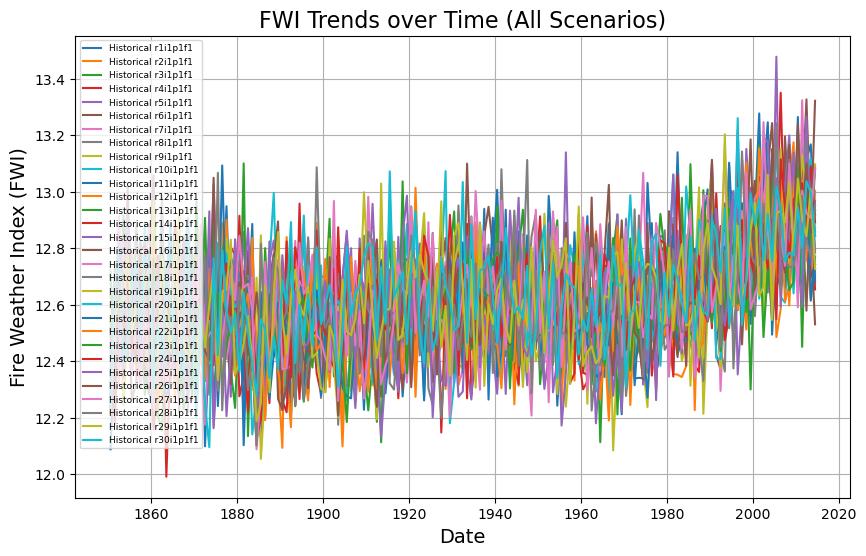

In [5]:
def plot_fwi_trends(datasets, labels, title):
    """ 
    Plot FWI trends over time for given datasets. 
    
    Args:
        datasets (list): List of xarray datasets.
        labels (list): Corresponding labels for each dataset.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(10, 6))
    
    # Plot each dataset
    for dataset, label in zip(datasets, labels):
        plt.plot(
            dataset['time'], 
            dataset['fwisa'].mean(dim=['lat', 'lon']), 
            label=label
        )
    
    # Plot customization
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=14)
    plt.title(title, fontsize=16)
    plt.legend(fontsize=6.5)
    plt.grid(True)
    plt.show()

# Group datasets and labels

labels_all_scenarios = (
    [f'Historical r{i}i1p1f1' for i in range(1, 31)] )

# Plot FWI trends for all scenarios
plot_fwi_trends(datasets_historical, labels_all_scenarios, 'FWI Trends over Time (All Scenarios)')

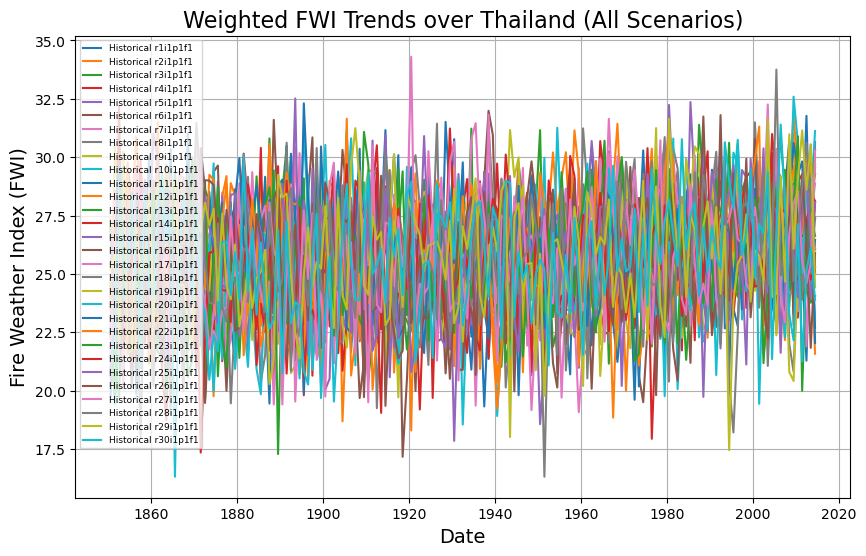

In [6]:
def plot_fwi_trends_weighted(datasets, labels, title):
    """ 
    Plot FWI trends over time for given datasets. 
    
    Args:
        datasets (list): List of xarray datasets.
        labels (list): Corresponding labels for each dataset.
        title (str): Title for the plot.
    """

    plt.figure(figsize=(10, 6))
    
    # Plot each dataset
    for dataset, label in zip(datasets, labels):
        plt.plot(
            dataset['time'], 
            (dataset['fwisa'].sel(lat=thailand_lat_range, lon=thailand_lon_range)).weighted(areacella_th['area']).mean(dim=['lat', 'lon']), 
            label=label
        )
    
    # Plot customization
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=14)
    plt.title(title, fontsize=16)
    plt.legend(fontsize=6.5)
    plt.grid(True)
    plt.show()

# Group datasets and labels


labels_all_scenarios = (
    [f'Historical r{i}i1p1f1' for i in range(1, 31)]
)

# Plot FWI trends for all scenarios
plot_fwi_trends_weighted(datasets_historical, labels_all_scenarios, 'Weighted FWI Trends over Thailand (All Scenarios)')

In [15]:

def plot_fwi_trends_weighted_with_ensemble(dataset, title, area_weights):
    """
    Plot FWI trends for all ensemble members, including their mean and standard deviation.
    
    Args:
        dataset (xarray.Dataset): The dataset containing 'fwisa' with dimensions (ensemble, time, lat, lon).
        title (str): Title of the plot.
        area_weights (xarray.DataArray): The area weights for the grid, with dimensions (lat, lon).
    """
    plt.figure(figsize=(14, 8))
    
    # Plot each ensemble member in light colors
    for i in range(dataset.dims['ensemble']):
        spatial_mean = (
            dataset.isel(ensemble=i)['fwisa']
            .weighted(area_weights)
            .mean(dim=['lat', 'lon'], skipna=True)
        )
        plt.plot(dataset['time'], spatial_mean, color='lightgrey', alpha=0.1)
    
    # Compute ensemble mean and standard deviation
    spatial_mean_all = (
        dataset['fwisa']
        .weighted(area_weights)
        .mean(dim=['lat', 'lon'], skipna=True)
    )  # Resulting shape: (ensemble, time)
    
    ensemble_mean = spatial_mean_all.mean(dim='ensemble')
    ensemble_std = spatial_mean_all.std(dim='ensemble')

    # Plot ensemble mean and standard deviation
    plt.plot(dataset['time'], ensemble_mean, color='blue', label='Ensemble Mean', linewidth=2)
    plt.fill_between(
        dataset['time'].values,
        (ensemble_mean - ensemble_std).values,
        (ensemble_mean + ensemble_std).values,
        color='blue',
        alpha=0.2,
        label='Ensemble Std Dev'
    )

    # Add labels, title, and legend
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('FWI', fontsize=14)
    plt.title(title, fontsize=16)
    plt.legend(fontsize=10)
    plt.grid(True)
    plt.show()


In [16]:
datasets_historical_combined = xr.concat(datasets_historical, dim='ensemble')
historical_data_th = datasets_historical_combined.sel(lat=thailand_lat_range, lon=thailand_lon_range)
ensemble_mean_historical_th = (historical_data_th.weighted(areacella_th['area']).mean(dim=['lat', 'lon'])).mean(dim='ensemble')
ensemble_std_historical_th = (historical_data_th.weighted(areacella_th['area']).mean(dim=['lat', 'lon'])).std(dim='ensemble')

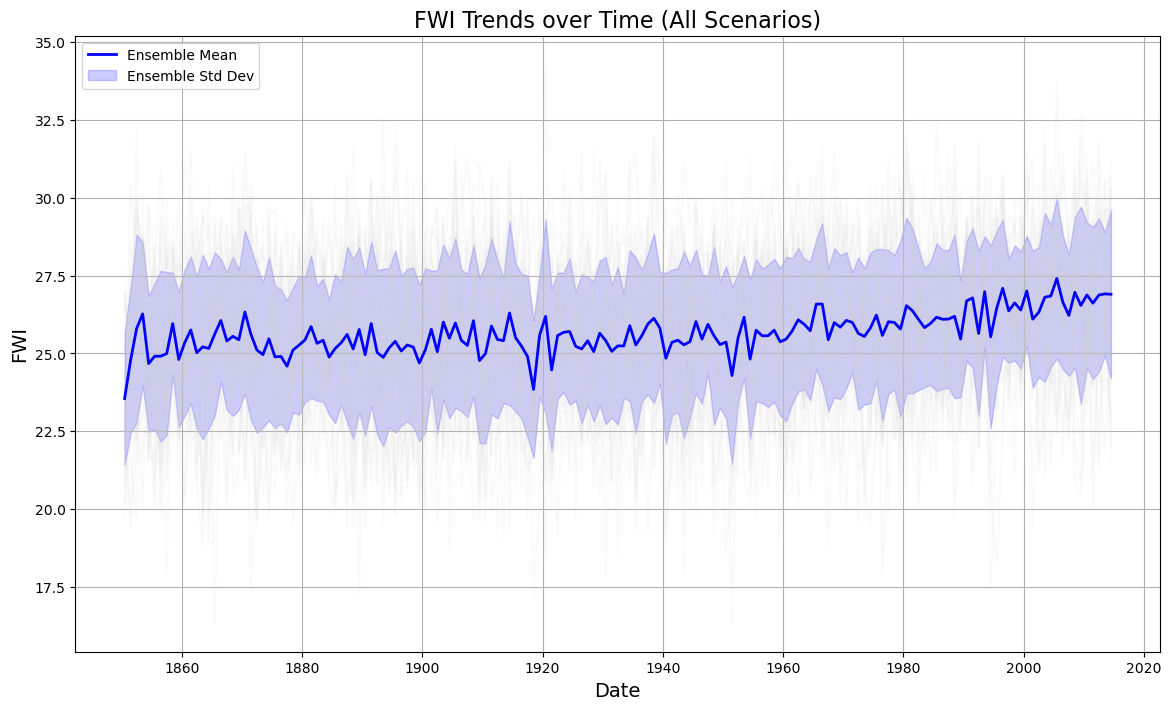

In [17]:
# Call the function
plot_fwi_trends_weighted_with_ensemble(
    datasets_historical_combined,
    "FWI Trends over Time (All Scenarios)",
    areacella_th['area']
)

In [11]:
print(datasets_historical_combined['fwisa'])

<xarray.DataArray 'fwisa' (ensemble: 30, time: 165, lat: 72, lon: 144)>
dask.array<concatenate, shape=(30, 165, 72, 144), dtype=float64, chunksize=(1, 165, 72, 144), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 1.25 3.75 6.25 8.75 11.25 ... 351.2 353.8 356.2 358.8
  * lat      (lat) float64 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * time     (time) datetime64[ns] 1850-07-01T06:00:00 ... 2014-07-01T06:00:00
Dimensions without coordinates: ensemble
Attributes:
    method_fwisa:   Annual peak of a 90 days average
    units:          1
    long_name:      Seasonal Average Of The Fire Weather Index
    standard_name:  fire_weather_index


In [ ]:
print([type(ds) for ds in historical_data_th])